In [18]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
def position_frequency_matrix(seq: list[str]):
    # переводим список строк в список списков -> np.array
    seq = np.array([list(x) for x in seq])

    nucleotides = np.array(['A', 'T', 'G', 'C'])

    # для каждого нуклеотида считаем частоту его встречаемости (numpy поэлементно сравнивает каждый элемент нашей матрицы с нуклеотидом ->
    # получаем матрицу из нулей и единиц
    count_matrix = np.array([
        np.sum(seq == base, axis=0) for base in nucleotides
    ])
    
    return count_matrix


def position_probability_matrix(pfm: np.ndarray|list[list[int]], alpha=0.1):
    pfm = pfm + alpha
    ppm = pfm / np.sum(pfm, axis = 0)
    return ppm

def shennon(ppm: np.ndarray|list[list[int]]):
    entropy_matrix = [[None for _ in range(len(ppm[0]))] for _ in range(len(ppm))]
    for i in range(len(ppm)):
        for k in range(len(ppm[0])):
            p = ppm[i][k]
            if p == 0:
                entropy_matrix[i][k] = 0
            else:
                entropy_matrix[i][k] = - p * np.log2(p)

    return np.sum(entropy_matrix, axis=0)
            
def information_content(entropy: np.ndarray|list[int]):
    return 2 - np.array(entropy)

In [16]:
sites = ["GAGGTAAAC", "TCCGTAAGC", "CAGGTTGGA",
         "ACAGTCAGC", "TAGGTCAGC", "CAGGTCAGC",
         "CAGGTCGAT", "CAGGTCAGC", "CAGGTCAGC",
         "CAGGTTGGC"]
pfm = position_frequency_matrix(sites)
print(pfm)

ppm = position_probability_matrix(pfm)
print(ppm)
entropy = shennon(ppm)
print(entropy)
ic = information_content(entropy)
print(ic)

[[ 1  8  1  0  0  2  7  2  1]
 [ 2  0  0  0 10  2  0  0  1]
 [ 1  0  8 10  0  0  3  8  0]
 [ 6  2  1  0  0  6  0  0  8]]
[[0.10576923 0.77884615 0.10576923 0.00961538 0.00961538 0.20192308
  0.68269231 0.20192308 0.10576923]
 [0.20192308 0.00961538 0.00961538 0.00961538 0.97115385 0.20192308
  0.00961538 0.00961538 0.10576923]
 [0.10576923 0.00961538 0.77884615 0.97115385 0.00961538 0.00961538
  0.29807692 0.77884615 0.00961538]
 [0.58653846 0.20192308 0.10576923 0.00961538 0.00961538 0.58653846
  0.00961538 0.00961538 0.77884615]]
[1.60312107 0.87576168 1.03086909 0.23429203 0.23429203 1.44801367
 1.02532307 0.87576168 1.03086909]
[0.39687893 1.12423832 0.96913091 1.76570797 1.76570797 0.55198633
 0.97467693 1.12423832 0.96913091]


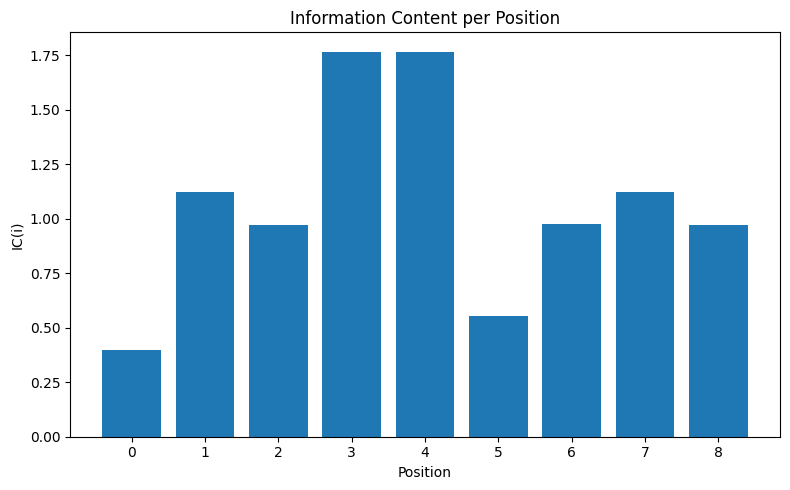

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(range(len(ic)), ic)

plt.xlabel("Position")
plt.ylabel("IC(i)")
plt.title("Information Content per Position")

plt.xticks(range(len(ic)))
plt.tight_layout()
plt.show()

вообще то что мы считали это не совсем IC, это кажется матожидание IC (ну судя по википедии). И где больше одинаковых позиций там больше. вроде все согласуется.